In [ ]:
# Ridge Regression

# Ridge Regression — конспект


Overfitting (веса слишком подстроились, скачут) → Ridge помогает. Увеличиваешь alpha → веса сжимаются → кривая выпрямляется → красная линия перестаёт гнаться за каждой точкой.
Underfitting (модель не дотягивает, слишком плоская/простая) → Ridge не решение, а наоборот, если тут ещё добавить alpha — станет только хуже, модель станет ещё более плоской и ещё сильнее "недотянет". В этом случае нужно:
либо уменьшить alpha (если он и так уже стоит, и это причина недообучения)
либо дать модели больше "инструментов" — например, добавить PolynomialFeatures с нужной степенью, если данные нелинейные (как в твоём примере с параболой)

![ridge](./ridge.png)

## Зачем это вообще нужно

Регуляризация = способ бороться с **overfitting** (переобучением). Чем меньше у модели "свободы" крутить свои параметры как угодно, тем сложнее ей подстроиться под шум в данных вместо реальной закономерности.

Для полиномиальной модели можно просто уменьшить степень полинома. Для линейной модели регуляризацию делают иначе — **ограничивают веса модели**, не давая им расти слишком сильно.

Ridge regression (она же **Tikhonov regularization**) — один из способов такого ограничения.

---

## Формула стоимости (cost function)

```
J(θ) = MSE(θ) + (α/m) * Σ θᵢ²      (сумма от i=1 до n)
```

В псевдокоде:

```js
function costFunction(weights, alpha, m) {
  const mse = calculateMSE(weights); // обычная ошибка модели
  const penalty = (alpha / m) * weights.reduce((sum, w) => sum + w * w, 0);
  return mse + penalty;
}
```

| Символ | Что это |
|---|---|
| `MSE(θ)` | обычная ошибка предсказания |
| `Σ θᵢ²` | сумма квадратов весов — показатель, насколько веса вообще большие |
| `α` (альфа) | ручка регуляризации, крутишь сам (0, 1, 10, 100...) |
| `m` | кол-во примеров в датасете, просто нормировка |
| `θ₀` | bias/intercept — **не** штрафуется (сумма начинается с i=1, не с 0), потому что он просто двигает линию вверх-вниз, а не отвечает за "резкость" кривой |

**Суть:** модель теперь минимизирует не только ошибку, а "ошибку + штраф за большие веса". Приходится искать баланс.

### Что значит α на графике

- **α = 0** → обычная линейная/полиномиальная регрессия, без ограничений → модель может переобучиться (дёргается по каждой точке)
- **α среднее** → баланс между точностью и гладкостью
- **α очень большое** → все веса задавлены почти до нуля → получается плоская линия на уровне среднего `y`

Это компромисс: регуляризация **увеличивает bias** (систематическую ошибку/упрощение), но **уменьшает variance** (чувствительность к шуму) — модель хуже точно повторяет тренировочные данные, зато лучше обобщается на новых.

> ⚠️ Перед Ridge данные обязательно нужно масштабировать (`StandardScaler`). Штраф зависит от размера весов, а размер весов зависит от масштаба признаков — если один признак в тысячах, а другой в долях, их веса несравнимы просто из-за единиц измерения, а не из-за важности.

---

## Разбор графика (Figure 4-18)

**Левый график** — обычная линейная регрессия + Ridge:
- `α=0` (синий пунктир) — обычная прямая, без штрафа
- `α=10` (зелёный) — чуть более "сдержанный" наклон
- `α=100` (красный) — почти плоская линия, близко к среднему `y`

**Правый график** — те же данные, но сначала раздутые в полином 10-й степени (`PolynomialFeatures(degree=10)`), отмасштабированные, и уже потом применён Ridge:
- `α=0` (синий) — дикие скачки вверх-вниз, классический overfitting на высокой степени полинома
- `α=1e-05` (зелёный) — почти без штрафа, всё ещё сильно изгибается
- `α=1` (красный) — гладкая, разумная кривая

Вывод графика: чем выше α, тем более "спокойные" (менее экстремальные) предсказания.

---

## Формула закрытого решения (closed-form / Normal Equation)

Обычная формула линейной регрессии (без регуляризации):
```
θ = (XᵀX)⁻¹ Xᵀy
```

Ridge-версия — **то же самое + один добавленный штрафующий член**:
```
θ = (XᵀX + αA)⁻¹ Xᵀy
```

Разница — только `+ αA` перед инвертированием. Остальное не меняется.

### Что за буквы

- **X** — матрица признаков (таблица: строки — примеры, столбцы — фичи)
- **y** — вектор ответов
- **Xᵀ** (транспонирование) — просто "переворот" матрицы, строки становятся столбцами:

```js
function transpose(matrix) {
  return matrix[0].map((_, col) => matrix.map(row => row[col]));
}
```

- **⁻¹** (обратная матрица) — аналог деления, только для матриц (как `1/x` для чисел)
- **A** — identity-матрица (единичная), но с **0 в левом верхнем углу** (соответствует нерегуляризуемому θ₀):

```
A = [
  [0, 0, 0],
  [0, 1, 0],
  [0, 0, 1]
]
```

- **α** — то же число-ручка, что и в cost function

### Псевдокод целиком

```js
function ridgeClosedForm(X, y, alpha) {
  const Xt = transpose(X);
  const XtX = matMul(Xt, X);
  const A = identityMatrixWithZeroCorner(X[0].length);
  const regularized = matAdd(XtX, matScale(A, alpha)); // XᵀX + αA
  const inverted = matInverse(regularized);
  const XtY = matMul(Xt, y);
  return matMul(inverted, XtY);
}
```

Если `α = 0` → `αA` — матрица нулей → формула превращается обратно в обычный Normal Equation.
Если `α` растёт → добавка "разбавляет" `XᵀX`, из-за чего получаются меньшие, более сглаженные веса.

---

## На практике (sklearn)

```python
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])
```

Или через градиентный спуск (SGD):

```python
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None,
                        max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())
```

- `penalty="l2"` — говорит SGD добавлять именно ridge-штраф (квадрат весов)
- обрати внимание: тут `alpha` передают как `0.1 / m` — потому что в SGD нет автоматического деления на `m`, как в формуле выше, поэтому его прописывают руками, чтобы результат совпадал с `Ridge(alpha=0.1)`

**Совет:** `RidgeCV` — то же самое, но с автоматическим подбором `alpha` через кросс-валидацию (аналог `GridSearchCV`, но заточен под ridge и работает быстрее).

---

## TL;DR

Ridge = обычная линейная регрессия + штраф за большие веса (`α * Σθᵢ²`). Чем больше `α`, тем сильнее модель "боится" больших весов → тем более гладкий/плоский получается результат. Это как линтер со строгими правилами: код становится менее "заточенным" под конкретный кейс, зато надёжнее работает в целом.

In [90]:
from sklearn.linear_model import Ridge
import numpy as np
from sklearn.linear_model import SGDRegressor
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
m = 200  # number of instances
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X**2 + X + 2 + rng.standard_normal((m, 1))


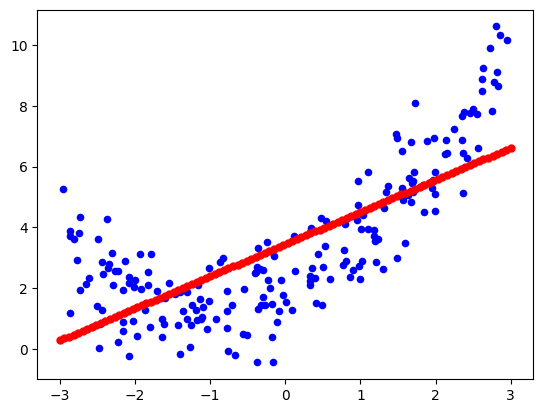

In [91]:
ridge_reg = Ridge(alpha=10, solver="cholesky")
ridge_reg.fit(X, y)
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
y_new = ridge_reg.predict(X_new)

plt.scatter(X, y, color="b", s=20)               # синие точки — исходные данные
plt.scatter(X_new, y_new, color="r", s=25)       # красная линия — предсказания модели

In [ ]:
sgd_reg = SGDRegressor(
    penalty="l2", alpha=0.1 / m, tol=None, max_iter=1000, eta0=0.01, random_state=42
)
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([5.06208065])

In [ ]:
# Lasso Regression